In [ ]:
## Installation required
## In qbraid we need to run the cell everytime we open a new session

!pip install qiskit[visualization]
# Use the following if you are on MacOS/zsh
#!pip install 'qiskit[visualization]'==1.1.0
!pip install qiskit_ibm_runtime
!pip install qiskit_aer
!pip install matplotlib
!pip install pylatexenc
!pip install prototype-zne

In [2]:
import qiskit
qiskit.__version__

'2.1.1'

In [3]:
## Import packages

#from math import pi
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Gate
from qiskit_aer import AerSimulator, QasmSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
import time

In [4]:
## Circuit setup

n = 3 #No. of key qubits to recover
x = 1 #x denotes the additional length of the key stream, other than key length, n. If key stream length is n+2, then x = 2
select = 7 #It represents the  number of select variables each having 1 qubit
keysize = pow(2,select) #It represents the  number of key qubits used as counter
lfsr_size = 69
nfsr_size = 90
z_size = 135 # Update here for running different rounds of initialiation phase
ks_size = n+x

l = QuantumRegister(lfsr_size, name='lfsr')
b = QuantumRegister(nfsr_size, name='nfsr') 
key = QuantumRegister(keysize, name='key')
c = QuantumRegister(2, name='c')
z = QuantumRegister(z_size, name='z')
z1 = QuantumRegister(ks_size, name='z1')
ancilla = QuantumRegister(2, 'anc')
ancilla_h = QuantumRegister(16, 'anc_h')

r_key = QuantumRegister(n, 'r_key')
rev_ks = QuantumRegister(n+x, 'rev_ks')
r_ancilla = QuantumRegister(n+x, 'r_ancilla')
r_output = QuantumRegister(1, name = 'r_output')

num_qbt = (lfsr_size+nfsr_size+keysize+2+z_size+ks_size+2+16+n+n+x+n+x+1) #It represents the total of qubits required
cr = ClassicalRegister(n, name='creg')
qc = QuantumCircuit(l, b, key, c, z, z1, ancilla, ancilla_h, r_key, rev_ks, r_ancilla, r_output, cr)

In [5]:
num_qubits = qc.num_qubits
print("Number of qubits:", num_qubits)

Number of qubits: 458


In [6]:
def mcx_3_decomposed(qc: QuantumCircuit, controls: list, target, ancilla):
    """
    It decomposes a 3-controlled X gate using CCX (Toffoli) gates and 1 ancilla
    """
    assert len(controls) == 3 #3 control qubits

    c0, c1, c2 = controls
    
    qc.ccx(c0, c1, ancilla) #To combine (c0 AND c1) into ancilla
    
    qc.ccx(ancilla, c2, target) #To combine (ancilla AND c2) into target
    
    qc.ccx(c0, c1, ancilla) #Uncompute ancilla

In [7]:
def mcx_4_decomposed(qc: QuantumCircuit, controls: list, target, ancillas: list):
    """
    It decomposes a 4-controlled X gate using CCX (Toffoli) gates and 2 ancilla qubits.
    """
    assert len(controls) == 4 #4 control qubits
    assert len(ancillas) == 2 #2 ancilla qubits

    c0, c1, c2, c3 = controls
    a0, a1 = ancillas
    t = target
    
    qc.ccx(c0, c1, a0) #To combine (c0 AND c1) into a0
    
    qc.ccx(a0, c2, a1) #To combine (a0 AND c2) into a1
    
    qc.ccx(a1, c3, t) #To combine (a1 AND c3) into t
    
    #Uncompute ancillas
    qc.ccx(a0, c2, a1)
    qc.ccx(c0, c1, a0)

In [8]:
## y_out: target qubit
## The ancilla registers ('ancilla', 'ancilla_h') as follows.
# ancilla[0]: Used in 'mcx_3_decomposed' function.
# ancilla: Represents 2 ancillas used in 'mcx_4_decomposed' function.
# ancilla_h: Represents 16 ancillas named as c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,c11,c12,c13,c14,c15, respectively.

def h_func(x0, x1, x2, x3, x4, x5, x6, x7, x8, ancilla_h, y_out):
    c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,c11,c12,c13,c14,c15 = ancilla_h
    qc.ccx(x0,x1,c0) # c0: ancilla
    qc.x(x7) # complement of x7
    qc.x(x8) # complement of x8
    qc.ccx(x7, x8, c1) # c1: ancilla
    qc.x(x7) # uncompute x7
    qc.ccx(x7, x8, c2) # c2: ancilla
    qc.x(x7) # complement of x7
    qc.x(x8) # uncompute x8
    qc.ccx(x7, x8, c3) # c3: ancilla
    qc.x(x7) # uncompute x7
    qc.ccx(x0, x2, c4) # c4: ancilla
    qc.ccx(x0, x3, c5) # c5: ancilla
    qc.ccx(x0, x4, c6) # c6: ancilla
    qc.ccx(x0, x5, c7) # c7: ancilla
    qc.ccx(x0, x6, c8) # c8: ancilla
    qc.ccx(x7, x8, c9) # c9: ancilla
    qc.ccx(x1, x2, c10) # c10: ancilla
    qc.ccx(x1, x3, c11) # c11: ancilla
    qc.ccx(x1, x4, c12) # c12: ancilla
    qc.ccx(x2, x3, c13) # c13: ancilla
    qc.ccx(x2, x4, c14) # c14: ancilla
    qc.ccx(x3, x4, c15) # c15: ancilla

    qc.x(x6) # complement of x6
    mcx_3_decomposed(qc, [c0, x6, c3], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c4, x6, c3], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c7, x6, c2], y_out, ancilla[0])
    mcx_4_decomposed(qc, [x1, x5, x6, c2], y_out, ancilla)
    mcx_3_decomposed(qc, [c14, x6, c9], y_out, ancilla[0])
    mcx_4_decomposed(qc, [x3, x5, x6, c9], y_out, ancilla)
    qc.x(x6) # uncompute x6

    qc.x(x8) # complement of x8
    qc.ccx(c5, x8, y_out)
    qc.ccx(c10, x8, y_out)
    qc.x(x8) # uncompute x8
    qc.x(x7) # complement of x7
    qc.ccx(c6, x7, y_out)
    qc.ccx(c12, x7, y_out)
    qc.ccx(x3, x7, y_out)
    qc.x(x7) # uncompute x7
    qc.x(x5) # complement of x5
    mcx_3_decomposed(qc, [x1, x5, x8], y_out, ancilla[0])
    mcx_4_decomposed(qc, [x2, x5, x6, c3], y_out, ancilla)
    mcx_4_decomposed(qc, [x4, x5, x6, c3], y_out, ancilla)
    qc.x(x5) # uncompute x5
    
    mcx_3_decomposed(qc, [c0, x2, c1], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c0, x4, c1], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c0, x3, c2], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c0, x5, c2], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [c4, x3, c1], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c4, x4, c3], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c4, x5, c1], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [c5, x4, c2], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c5, x5, c2], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c5, x6, c2], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [c6, x5, c2], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c6, x6, c3], y_out, ancilla[0])

    qc.ccx(c8, x7, y_out)
    qc.ccx(c8, x8, y_out)
    qc.ccx(x0, c9, y_out)
    
    mcx_3_decomposed(qc, [c10, x3, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c10, x4, c3], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c10, x5, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c10, x6, c3], y_out, ancilla[0])
    qc.ccx(c10, x7, y_out)
    
    mcx_3_decomposed(qc, [c11, x4, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c11, x5, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c11, x6, c9], y_out, ancilla[0])
    qc.ccx(c11, x7, y_out)
    
    mcx_3_decomposed(qc, [c12, x5, c3], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c12, x6, c9], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [x1, x6, x7], y_out, ancilla[0])
    qc.cx(x1, y_out)
    
    mcx_3_decomposed(qc, [c13, x4, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c13, x5, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c13, x6, c9], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [c14, x5, c3], y_out, ancilla[0])
    qc.ccx(c14, x8, y_out)
    
    mcx_3_decomposed(qc, [x2, x5, x8], y_out, ancilla[0])
    qc.ccx(x2, c9, y_out)
    qc.cx(x2, y_out)
    
    mcx_3_decomposed(qc, [c15, x5, c2], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c15, x6, c2], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [x3, x6, c2], y_out, ancilla[0])
    qc.cx(c1, y_out)
    qc.ccx(x4, x7, y_out)
    qc.ccx(x5, c9, y_out)
    qc.cx(x5, y_out)
    qc.cx(x6, y_out)
    
    # Uncompute ancillas
    qc.ccx(x0,x1,c0) # c0: ancilla
    qc.x(x7) # complement of x7
    qc.x(x8) # complement of x8
    qc.ccx(x7, x8, c1) # c1: ancilla
    qc.x(x7) # uncompute x7
    qc.ccx(x7, x8, c2) # c2: ancilla
    qc.x(x7) # complement of x7
    qc.x(x8) # uncompute x8
    qc.ccx(x7, x8, c3) # c3: ancilla
    qc.x(x7) # uncompute x7
    qc.ccx(x0, x2, c4) # c4: ancilla
    qc.ccx(x0, x3, c5) # c5: ancilla
    qc.ccx(x0, x4, c6) # c6: ancilla
    qc.ccx(x0, x5, c7) # c7: ancilla
    qc.ccx(x0, x6, c8) # c8: ancilla
    qc.ccx(x7, x8, c9) # c9: ancilla
    qc.ccx(x1, x2, c10) # c10: ancilla
    qc.ccx(x1, x3, c11) # c11: ancilla
    qc.ccx(x1, x4, c12) # c12: ancilla
    qc.ccx(x2, x3, c13) # c13: ancilla
    qc.ccx(x2, x4, c14) # c14: ancilla
    qc.ccx(x3, x4, c15) # c15: ancilla

In [9]:
def h_func_rev(x0, x1, x2, x3, x4, x5, x6, x7, x8, ancilla_h, y_out):
    c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,c11,c12,c13,c14,c15 = ancilla_h
    
    qc.ccx(x0,x1,c0) # c0: ancilla
    qc.x(x7) # complement of x7
    qc.x(x8) # complement of x8
    qc.ccx(x7, x8, c1) # c1: ancilla
    qc.x(x7) # uncompute x7
    qc.ccx(x7, x8, c2) # c2: ancilla
    qc.x(x7) # complement of x7
    qc.x(x8) # uncompute x8
    qc.ccx(x7, x8, c3) # c3: ancilla
    qc.x(x7) # uncompute x7
    qc.ccx(x0, x2, c4) # c4: ancilla
    qc.ccx(x0, x3, c5) # c5: ancilla
    qc.ccx(x0, x4, c6) # c6: ancilla
    qc.ccx(x0, x5, c7) # c7: ancilla
    qc.ccx(x0, x6, c8) # c8: ancilla
    qc.ccx(x7, x8, c9) # c9: ancilla
    qc.ccx(x1, x2, c10) # c10: ancilla
    qc.ccx(x1, x3, c11) # c11: ancilla
    qc.ccx(x1, x4, c12) # c12: ancilla
    qc.ccx(x2, x3, c13) # c13: ancilla
    qc.ccx(x2, x4, c14) # c14: ancilla
    qc.ccx(x3, x4, c15) # c15: ancilla
    #########################################################
    qc.cx(x6, y_out)
    qc.cx(x5, y_out)
    qc.ccx(x5, c9, y_out)
    qc.ccx(x4, x7, y_out)
    qc.cx(c1, y_out)
    mcx_3_decomposed(qc, [x3, x6, c2], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [c15, x6, c2], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c15, x5, c2], y_out, ancilla[0])
    
    qc.cx(x2, y_out)
    qc.ccx(x2, c9, y_out)
    mcx_3_decomposed(qc, [x2, x5, x8], y_out, ancilla[0])

    qc.ccx(c14, x8, y_out)
    mcx_3_decomposed(qc, [c14, x5, c3], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [c13, x6, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c13, x5, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c13, x4, c9], y_out, ancilla[0])
    
    qc.cx(x1, y_out)
    mcx_3_decomposed(qc, [x1, x6, x7], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [c12, x6, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c12, x5, c3], y_out, ancilla[0])
    
    qc.ccx(c11, x7, y_out)
    mcx_3_decomposed(qc, [c11, x6, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c11, x5, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c11, x4, c9], y_out, ancilla[0])
    
    qc.ccx(c10, x7, y_out)
    mcx_3_decomposed(qc, [c10, x6, c3], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c10, x5, c9], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c10, x4, c3], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c10, x3, c9], y_out, ancilla[0])
    
    qc.ccx(x0, c9, y_out)
    qc.ccx(c8, x8, y_out)
    qc.ccx(c8, x7, y_out)
    
    mcx_3_decomposed(qc, [c6, x6, c3], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c6, x5, c2], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [c5, x6, c2], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c5, x5, c2], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c5, x4, c2], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [c4, x5, c1], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c4, x4, c3], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c4, x3, c1], y_out, ancilla[0])
    
    mcx_3_decomposed(qc, [c0, x5, c2], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c0, x3, c2], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c0, x4, c1], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c0, x2, c1], y_out, ancilla[0])
    
    qc.x(x5) # uncompute x5
    mcx_4_decomposed(qc, [x4, x5, x6, c3], y_out, ancilla)
    mcx_4_decomposed(qc, [x2, x5, x6, c3], y_out, ancilla)
    mcx_3_decomposed(qc, [x1, x5, x8], y_out, ancilla[0])
    qc.x(x5) # complement of x5
    qc.x(x7) # uncompute x7
    qc.ccx(x3, x7, y_out)
    qc.ccx(c12, x7, y_out)
    qc.ccx(c6, x7, y_out)
    qc.x(x7) # complement of x7
    qc.x(x8) # uncompute x8
    qc.ccx(c10, x8, y_out)
    qc.ccx(c5, x8, y_out)
    qc.x(x8) # complement of x8
    
    qc.x(x6) # uncompute x6
    mcx_4_decomposed(qc, [x3, x5, x6, c9], y_out, ancilla)
    mcx_3_decomposed(qc, [c14, x6, c9], y_out, ancilla[0])
    mcx_4_decomposed(qc, [x1, x5, x6, c2], y_out, ancilla)
    mcx_3_decomposed(qc, [c7, x6, c2], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c4, x6, c3], y_out, ancilla[0])
    mcx_3_decomposed(qc, [c0, x6, c3], y_out, ancilla[0])
    qc.x(x6) # complement of x6
    
    # Uncompute ancillas
    qc.ccx(x0,x1,c0) # c0: ancilla
    qc.x(x7) # complement of x7
    qc.x(x8) # complement of x8
    qc.ccx(x7, x8, c1) # c1: ancilla
    qc.x(x7) # uncompute x7
    qc.ccx(x7, x8, c2) # c2: ancilla
    qc.x(x7) # complement of x7
    qc.x(x8) # uncompute x8
    qc.ccx(x7, x8, c3) # c3: ancilla
    qc.x(x7) # uncompute x7
    qc.ccx(x0, x2, c4) # c4: ancilla
    qc.ccx(x0, x3, c5) # c5: ancilla
    qc.ccx(x0, x4, c6) # c6: ancilla
    qc.ccx(x0, x5, c7) # c7: ancilla
    qc.ccx(x0, x6, c8) # c8: ancilla
    qc.ccx(x7, x8, c9) # c9: ancilla
    qc.ccx(x1, x2, c10) # c10: ancilla
    qc.ccx(x1, x3, c11) # c11: ancilla
    qc.ccx(x1, x4, c12) # c12: ancilla
    qc.ccx(x2, x3, c13) # c13: ancilla
    qc.ccx(x2, x4, c14) # c14: ancilla
    qc.ccx(x3, x4, c15) # c15: ancilla

In [10]:
## 0. Initialization of Key, IV, PD ##
def key_iv_setup():
    #Key_bin = "00001111"*16 #Key size = 128
    #Key_bin = "00001111000011110000111100001111000011110000111100001111000011110000111100001111000011110000111100001111000011110000111100001111"
    #Key_bin = "10011101110001010100111011111110100011010000010100011011011001001010000111001000000101101110110111001010100111000010011100111101"
    #Key_bin = "00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000"
    #Key_bin = "11111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111"
    Key_bin = "11101110001010100111011111110100011010000010100011011011001001010000111001000000101101000110111001010000101000010011100111101"
    for i in range(len(Key_bin)):
        if (Key_bin[i] == '1'):
            qc.x(key[i+n])
    #IV_bin = "00001111"*16 #IV size = 128
    #IV_bin = "00001111000011110000111100001111000011110000111100001111000011110000111100001111000011110000111100001111000011110000111100001111"
    #IV_bin = "10011101001000110011010101101101100111110001100010111101000101010010000101101111110110000001100011001100101111001101000110100110"
    #IV_bin = "00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000"
    #IV_bin = "11111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111"
    IV_bin = "10011101001000011111010101101101100111110001100010111111000101010010000101101111110110000001100011001110101111101101000110100110"
    for i in range(90):
        if (IV_bin[i] == '1'):
            qc.x(b[i])
    for i in range(38):
        if (IV_bin[90+i] == '1'):
            qc.x(l[i])
    for i in range(38,60):
        qc.x(l[i])

In [11]:
## 1. Output functions
def output_func(z, c0, c1):
    for i in [1, 5, 11, 22, 36, 53, 72, 80, 84]:
        qc.cx(b[i], z)
    x = [5, 13, 30]
    y = [16, 15, 42]
    for i in range(len(x)):
        qc.ccx(l[x[i]], l[y[i]], z)
    qc.ccx(l[22], c1, z)
    h_func(l[7], l[33], l[38], l[50], l[59], c0, b[85], b[41], b[9], ancilla_h, z)

def output_func_rev(z, c0, c1):
    h_func_rev(l[7], l[33], l[38], l[50], l[59], c0, b[85], b[41], b[9], ancilla_h, z)
    qc.ccx(l[22], c1, z)
    x = [5, 13, 30]
    y = [16, 15, 42]
    for i in range(len(x)):
        qc.ccx(l[x[i]], l[y[i]], z)
    for i in [1, 5, 11, 22, 36, 53, 72, 80, 84]:
        qc.cx(b[i], z)
    

def output_func_ks(z1):
    for i in [1, 5, 11, 22, 36, 53, 72, 80, 84]:
        qc.cx(b[i], z1)
    x = [5, 13, 30, 22]
    y = [16, 15, 42, 67]
    for i in range(len(x)):
        qc.ccx(l[x[i]], l[y[i]], z1)
    h_func(l[7], l[33], l[38], l[50], l[59], l[62], b[85], b[41], b[9], ancilla_h, z1)

def output_func_ks_rev(z1):
    h_func_rev(l[7], l[33], l[38], l[50], l[59], l[62], b[85], b[41], b[9], ancilla_h, z1)
    x = [5, 13, 30, 22]
    y = [16, 15, 42, 67]
    for i in range(len(x)):
        qc.ccx(l[x[i]], l[y[i]], z1)
    for i in [1, 5, 11, 22, 36, 53, 72, 80, 84]:
        qc.cx(b[i], z1)

In [12]:
## 2. g function
def g_func(b):
    for i in [24, 49, 79, 84]:
        qc.cx(b[i], b[0])
    x = [3, 10, 15, 25, 35, 55, 60]
    y = [59, 12, 16, 53, 42, 58, 74]
    for i in range(len(x)):
        qc.ccx(b[x[i]], b[y[i]], b[0])
    mcx_3_decomposed(qc, [b[20], b[22], b[23]], b[0], ancilla[0])
    mcx_3_decomposed(qc, [b[62], b[68], b[72]], b[0], ancilla[0])
    mcx_4_decomposed(qc, [b[77], b[80], b[81], b[83]], b[0], ancilla)

In [13]:
## 3. f functiom
def f_func(l):
    for i in [5, 12, 22, 28, 37, 45, 58]:
        qc.cx(l[i],l[0])

In [14]:
## 4. Key stream generation function
def atom_ks_gen():
    #Initialization
    for rnd in range(z_size):
        C = [0]*9 # len(C) = 9
        for i in range(len(C)):
            C[8-i] = (rnd >> i) & 1 
        if (C[2] == 1):
            qc.x(c[0])
        if (C[7] == 1):
            qc.x(c[1])
        output_func(z[rnd], c[0], c[1])
        g_func(b)
        qc.cx(l[0], b[0])
        qc.cx(key[rnd % 128], b[0]) # key[cnt] is replaced with key[rnd%128] as mentioned in the implementation provided by the Atom designer
        qc.cx(z[rnd], b[0])
        for i in range(89):
            qc.swap(b[i], b[i+1])
        f_func(l)
        qc.cx(z[rnd], l[0])
        for i in range(59):
            qc.swap(l[i], l[i+1])
        if (C[2] == 1):
            qc.x(c[0])
        if (C[7] == 1):
            qc.x(c[1])
    rnd  = 511
    #C = [0]*9 # len(C) = 9
    for i in range(len(C)):
        C[8-i] = (rnd >> i) & 1
    for i in range(len(C)):
        if (C[i] == 1):
            qc.x(l[60+i])
    #Key stream generation
    for rnd in range(ks_size):
        output_func_ks(z1[rnd])
        g_func(b)
        qc.cx(l[0], b[0])
        qc.cx(key[rnd%128], b[0])
        ## Using cswap gates (General formula) - output pin is key[0]
        for i in range(select-1, -1, -1):
            for j in range(pow(2,i)):
                qc.cswap(l[68-i], key[j], key[j+pow(2,i)]) 
        ################
        qc.cx(key[0], b[0])
        ## Using cswap gates (General formula) - reset key to original values
        for i in range(select):
            for j in range(pow(2,i)-1,-1,-1):
                qc.cswap(l[68-i], key[j], key[j+pow(2,i)])
        ################
        for i in range(89):
            qc.swap(b[i], b[i+1])
        f_func(l)
        for i in range(68):
            qc.swap(l[i], l[i+1])

In [15]:
## 5. Key stream generation function (in reverse order)
def atom_ks_gen_rev():
    #Key stream generation
    for rnd in range(ks_size):
        for i in range(67,-1,-1):
            qc.swap(l[i], l[i+1])
        f_func(l)
        for i in range(88,-1,-1):
            qc.swap(b[i], b[i+1])
        ## Using cswap gates 
        for i in range(select-1, -1, -1):
            for j in range(pow(2,i)):
                qc.cswap(l[68-i], key[j], key[j+pow(2,i)])
        ################ 
        qc.cx(key[0], b[0])
        ## Using cswap gates - reset key to original values
        for i in range(select):
            for j in range(pow(2,i)-1,-1,-1):
                qc.cswap(l[68-i], key[j], key[j+pow(2,i)])
        ################
        qc.cx(key[(ks_size-1-rnd)%128], b[0]) #Replaced 'rnd' with 'ks_size-1-rnd'
        qc.cx(l[0], b[0])
        g_func(b)
        output_func_ks_rev(z1[ks_size-1-rnd]) #Replaced 'rnd' with 'ks_size-1-rnd'
    #Initialization
    rnd  = 511
    C = [0]*9 # len(C) = 9
    for i in range(len(C)-1,-1,-1):
        C[8-i] = (rnd >> i) & 1
    for i in range(len(C)-1,-1,-1):
        if (C[i] == 1):
            qc.x(l[60+i])
    for rnd in range(z_size):
        for i in range(len(C)):
            C[8-i] = ((z_size-1-rnd) >> i) & 1 #Replaced 'rnd' with 'z_size-1-rnd'
        if (C[7] == 1):
            qc.x(c[1])
        if (C[2] == 1):
            qc.x(c[0])
        for i in range(58,-1,-1):
            qc.swap(l[i], l[i+1])
        qc.cx(z[z_size-1-rnd], l[0]) #Replaced 'rnd' with 'z_size-1-rnd'
        f_func(l)
        for i in range(88,-1,-1):
            qc.swap(b[i], b[i+1])
        qc.cx(z[z_size-1-rnd], b[0]) #Replaced 'rnd' with 'z_size-1-rnd'
        qc.cx(key[(z_size-1-rnd) % 128], b[0]) # Replaced 'rnd' with 'z_size-1-rnd'
        qc.cx(l[0], b[0])
        g_func(b)
        output_func_rev(z[z_size-1-rnd], c[0], c[1]) #Replaced 'rnd' with 'z_size-1-rnd'
        if (C[7] == 1):
            qc.x(c[1])
        if (C[2] == 1):
            qc.x(c[0])

In [16]:
def our_oracle(qc, r_key, r_ancilla, rev_ks, z1, r_output, n, x):
    #Preparing key in a superposition state
    for i in range(n): #For loading partial key
        qc.cx(r_key[i], key[i])
    atom_ks_gen()
    
    #Checking whether the generated key stream is equal to the given key stream
    for i in range(n+x):
        qc.cx(rev_ks[i], r_ancilla[i])
        qc.cx(z1[i], r_ancilla[i]) 
        qc.x(r_ancilla[i])
        
    #Set 'output' bit if the key stream is matched
    qc.mcx(r_ancilla, r_output)
    
    qc.barrier()
    
    #Uncompute to reset ancilla and key stream qubits
    for i in range(n+x):
        qc.x(r_ancilla[i])
        qc.cx(rev_ks[i], r_ancilla[i])
        qc.cx(z1[i], r_ancilla[i]) 
    qc.barrier()
    
    atom_ks_gen_rev()
    for i in range(n):
        qc.cx(r_key[i], key[i])
    qc.barrier()
        


In [17]:
#The diffuser function is available in Qiskit; Courtesey: https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/grover.ipynb
def diffuser(nqubits):
    qc = QuantumCircuit(nqubits)
    #nqubits = nqubits - 2
    #Apply transformation |s> -> |00...0> (H gates)
    for qubit in range(nqubits):
        qc.h(qubit)
    #Apply transformation |00...0> -> |11...1> (X gates)
    for qubit in range(nqubits):
        qc.x(qubit)    
    #Do multi-controlled Z gate
    qc.h(nqubits - 1)
    qc.mcx(list(range(nqubits - 1)), nqubits - 1) #multi-controlled Toffoli; replaced with qc.mct(list(range(nqubits - 1)), nqubits - 1)
    qc.h(nqubits - 1)
    #Apply transformation |11...1> -> |00...0> (X gates)
    for qubit in range(nqubits):
        qc.x(qubit)
    #Apply transformation |00...0> -> |s> (H gates)
    for qubit in range(nqubits):
        qc.h(qubit)
    #We will return the diffuser as a gate
    U_s = qc.to_gate()
    #U_s.name = "U$_s$"
    return U_s
    

In [18]:
#loading known key stream
ks_actual = '1000' # key should be '011'
for i in range(n+x):
    if (ks_actual[i] == "1"):
        qc.x(rev_ks[i])
for i in range(n):
    qc.h(r_key[i])
#Preparing output qubit
qc.x(r_output)
qc.h(r_output)
#qc.barrier()

start = time.process_time()
key_iv_setup()

#First Iteration
our_oracle(qc, r_key, r_ancilla, rev_ks, z1, r_output, n, x)
#qc.barrier()
qc.append(diffuser(n), r_key)
#qc.barrier()

#Second Iteration
our_oracle(qc, r_key, r_ancilla, rev_ks, z1, r_output, n, x)
#qc.barrier()
qc.append(diffuser(n), r_key)
#qc.barrier()


In [19]:
#qc.measure_all()
qc.measure(r_key, cr)

In [20]:
print("Circuit depth: ", qc.depth())

Circuit depth:  134576


In [21]:
# Simulate the quantum circuit
backend = QasmSimulator(method='matrix_product_state')
n_o_shots = 100 #1024
result = backend.run(qc.decompose(reps=1), shots=n_o_shots).result()
print("Time elapsed (in sec):", time.process_time() - start)
## Plot results
counts = result.get_counts()
print (counts)

Time elapsed (in sec): 714.359266208
{'011': 1, '000': 1, '010': 3, '101': 1, '100': 2, '110': 92}


In [22]:
b, c = max(counts.items(), key=lambda x: x[1])
print("Key is :", b[::-1], "with probability =", c/n_o_shots, "and count =", c, "when the initialization phase iterates for", z_size)
print(time.process_time() - start)

Key is : 011 with probability = 0.92 and count = 92 when the initialization phase iterates for 135
714.368892826


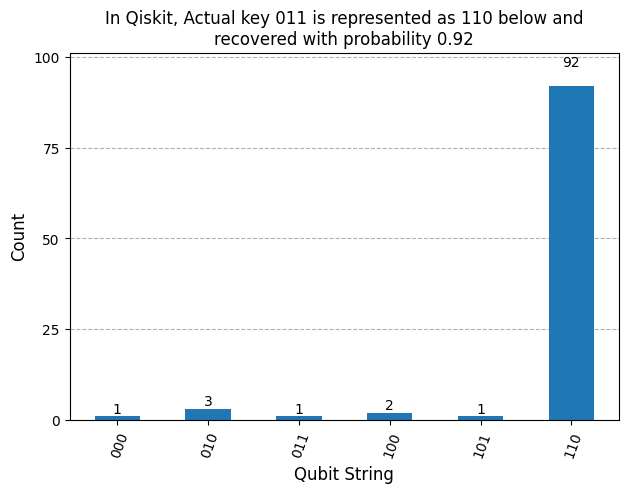

In [23]:
%matplotlib inline
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

figure = plot_histogram(counts, title = "In Qiskit, Actual key {0} is represented as {1} below and\nrecovered with probability {2:.2f}".format(b[::-1],b,c/n_o_shots))
# Label the axes
ax = figure.gca()  # Get the current axis
ax.set_xlabel('Qubit String', fontsize=12)  # Set x-axis label
ax.set_ylabel('Count', fontsize=12)  # Set y-axis label

# Save the plot as an image
figure.savefig("histogram.png")